In [1]:
from pathlib import Path
import csv
import datetime
import os
import sys
from dataclasses import dataclass
from typing import List, Tuple

notebook_dir = Path(os.getcwd())
project_root_dir = notebook_dir.parent
if str(project_root_dir) not in sys.path:
    sys.path.insert(0, str(project_root_dir))

import seaborn as sns
import matplotlib.pyplot as plt
import pyrallis
import pandas as pd
import numpy as np

from config import Config, TrainConfig
import logs

In [108]:
import importlib
importlib.reload(logs)

<module 'logs' from '/mnt/SharedOne/bpanthi/model_search/logs.py'>

In [2]:
study_dir = project_root_dir.joinpath("logs/hgf-20p")
trials_all = logs.read_study(study_dir)
df_all = logs.create_df(trials)
len(trials)

59

In [94]:
trials = []
for t in trials_all:
    if int(t.name[:8]) <= 20250611 and int(t.name[10:15]) <= 122728:
        trials.append(t)

df_till_now = logs.create_df(trials)

In [95]:
df = df_till_now.query("((optimizer == 'rmsprop' & lr == 0.001 & weight_decay == 0) | (optimizer == 'adagrad' & lr == 0.1 & weight_decay == 0)) & init == 'ku' & loss == 'mse' & batch_size == 1024")
df['hidden_layers'] = df['hidden_layers'].astype(str)
df

/tmp/ipykernel_240150/1546195213.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hidden_layers'] = df['hidden_layers'].astype(str)


,name,loss,batch_size,init,init_param,activation,hidden_layers,dropout,optimizer,lr,weight_decay,train_time,epoch,train_loss,val_loss
300,20250611-122728-AxkQ,mse,1024,ku,[],relu,[128],[],rmsprop,0.001,0.0,102.750000,1,7.390505,2.379644
301,20250611-122728-AxkQ,mse,1024,ku,[],relu,[128],[],rmsprop,0.001,0.0,102.750000,2,1.634454,1.395082
302,20250611-122728-AxkQ,mse,1024,ku,[],relu,[128],[],rmsprop,0.001,0.0,102.750000,3,1.243838,1.359420
303,20250611-122728-AxkQ,mse,1024,ku,[],relu,[128],[],rmsprop,0.001,0.0,102.750000,4,0.959399,1.256730
304,20250611-122728-AxkQ,mse,1024,ku,[],relu,[128],[],rmsprop,0.001,0.0,102.750000,5,0.857675,1.063515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5595,20250611-122728-VCfG,mse,1024,ku,[],leaky_relu,[512],[],rmsprop,0.001,0.0,86.316667,96,1.024713,1.795178
5596,20250611-122728-VCfG,mse,1024,ku,[],leaky_relu,[512],[],rmsprop,0.001,0.0,86.316667,97,1.084716,1.348934
5597,20250611-122728-VCfG,mse,1024,ku,[],leaky_relu,[512],[],rmsprop,0.001,0.0,86.316667,98,1.326738,1.226113
5598,20250611-122728-VCfG,mse,1024,ku,[],leaky_relu,[512],[],rmsprop,0.001,0.0,86.316667,99,1.071974,2.563291


[None]

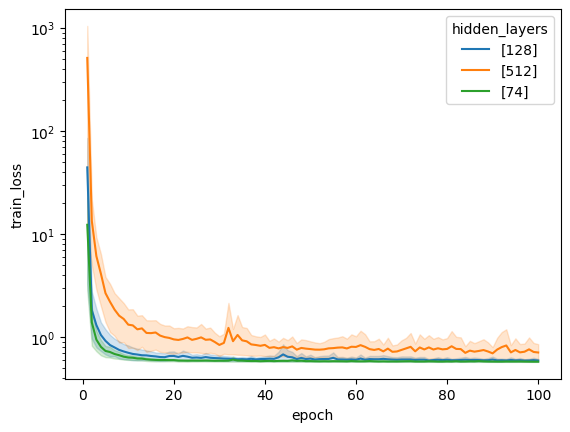

In [80]:
ax = sns.lineplot(df, x='epoch', y='train_loss', hue='hidden_layers')
ax.set(yscale='log')

[None]

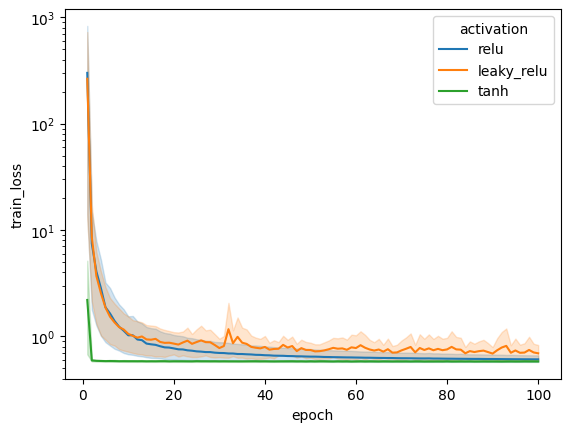

In [81]:
ax = sns.lineplot(df, x='epoch', y='train_loss', hue='activation')
ax.set(yscale='log')

In [98]:
df.groupby(['activation', 'hidden_layers', 'optimizer'])['val_loss'].min()

activation  hidden_layers  optimizer
leaky_relu  [128]          adagrad      0.986057
                           rmsprop      0.861137
            [512]          adagrad      1.519877
                           rmsprop      1.004832
            [74]           adagrad      0.916027
                           rmsprop      0.845900
relu        [128]          adagrad      1.039070
                           rmsprop      0.843546
            [512]          adagrad      2.146673
                           rmsprop      0.846009
            [74]           adagrad      0.935798
                           rmsprop      0.843523
tanh        [128]          adagrad      0.843639
                           rmsprop      0.843430
            [512]          adagrad      0.844715
                           rmsprop      0.843629
            [74]           adagrad      0.843543
                           rmsprop      0.843405
Name: val_loss, dtype: float64

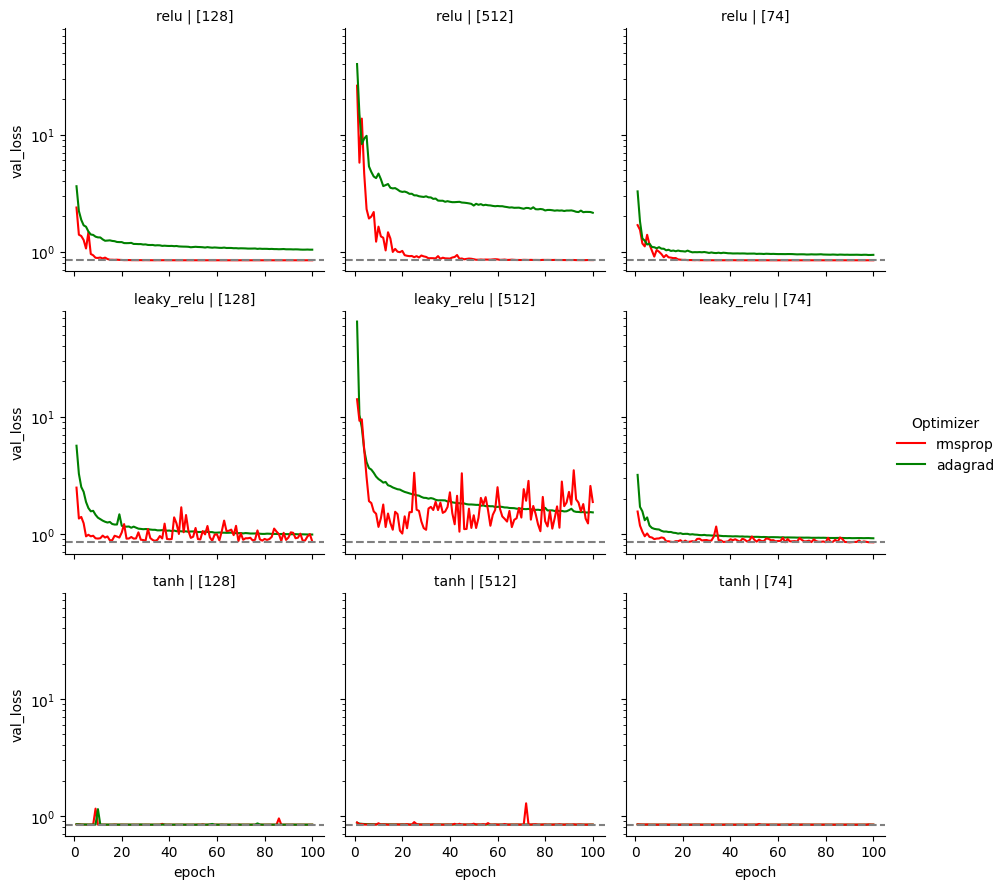

In [96]:
g = sns.FacetGrid(df, col="hidden_layers",  row="activation")
ax = g.map_dataframe(sns.lineplot, x="epoch", y="val_loss", hue='optimizer',  palette={"rmsprop": "red", "adagrad": "green"})
g.set_titles("{row_name} | {col_name}")
g.refline(y=df['val_loss'].min(),)
ax.set(yscale='log')
g.add_legend(title="Optimizer")
g.savefig("./val_loss_03.svg")

# Conclusion: Adagrad is not necessarily better than RMSProp when using MSE loss

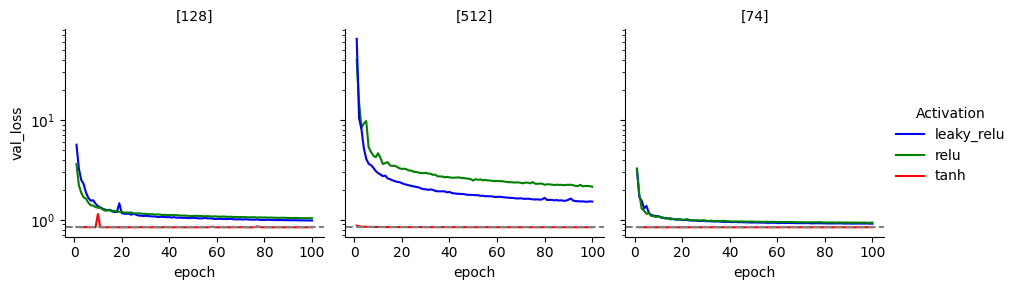

In [88]:
df_plot = df.query('optimizer == "adagrad"')
g = sns.FacetGrid(df_plot, col="hidden_layers")
ax = g.map_dataframe(sns.lineplot, x="epoch", y="val_loss", hue='activation', palette={"tanh": "red", "relu": "green", "leaky_relu": "blue"})
g.set_titles("{col_name}")
g.refline(y=df['val_loss'].min(),)
ax.set(yscale='log')
g.add_legend(title="Activation")
g.savefig("./val_loss_04.svg")

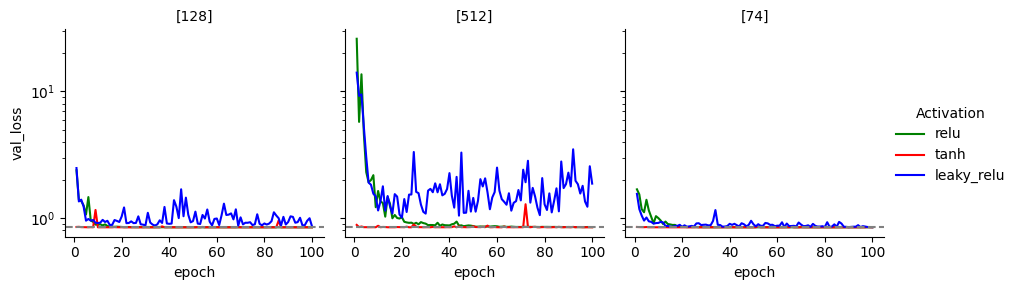

In [89]:
df_plot = df.query('optimizer == "rmsprop"')
g = sns.FacetGrid(df_plot, col="hidden_layers")
ax = g.map_dataframe(sns.lineplot, x="epoch", y="val_loss", hue='activation', palette={"tanh": "red", "relu": "green", "leaky_relu": "blue"})
g.set_titles("{col_name}")
g.refline(y=df['val_loss'].min(),)
ax.set(yscale='log')
g.add_legend(title="Activation")
g.savefig("./val_loss_04.svg")

In [93]:
df['val_loss'].min()

np.float64(0.8434053856700048)

In [91]:
df['train_loss'].min()

np.float64(0.5728990944404705)